# LM loss harness — next-token loss, made correct and observable

A tiny GPT trained on TinyShakespeare with the GPT-2 BPE tokenizer (`tiktoken`, vocab 50,257).
Everything between `model(tokens)` and the scalar loss is made explicit, printed, and checked.

Starting point:

```python
hidden = model(tokens)
logits = output_head(hidden)
loss = cross_entropy(
    logits[:, :-1].reshape(-1, vocab_size),
    tokens[:, 1:].reshape(-1),
)
```

The shift direction above is already right: the logit at position `t` is scored against the token at `t+1`.
What it lacks is any way to *see* that, plus padding masks, document-boundary masks, a perplexity sanity
check and a memory-aware path. Those are added below, and every claim is printed.

**Runtime.** Use a GPU runtime on Colab (Runtime → Change runtime type → T4): a few minutes.
On CPU only it takes roughly 1.5–2 hours, because Part 2 trains two seeds of two models.
Set `HARNESS_STEPS` / `HARNESS_SEEDS` environment variables only for quick debugging.

Contents: data and model → harness → items 1, 2, 3, 5, 6, 7 → training (+ the wrong-shift demonstration) → item 4 → Part 2.
Prose that quotes specific numbers refers to the committed run; the code cells print the numbers for whatever run you do.

In [1]:
# Colab ships torch; tiktoken may be missing.
import importlib, importlib.util, subprocess, sys
if importlib.util.find_spec("tiktoken") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tiktoken"], check=True)

import math, os, time, json, random, urllib.request
import torch, torch.nn as nn, torch.nn.functional as F
import tiktoken
import matplotlib.pyplot as plt

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IGNORE = -100   # F.cross_entropy's default ignore_index
print("torch", torch.__version__, "| device", DEVICE)

torch 2.14.1+cu130 | device cpu


## Data and tokenizer

TinyShakespeare is a sequence of speeches separated by blank lines (`NAME:\n text`). Each speech is treated as a
document and terminated with `<|endoftext|>`, the way GPT-2 was trained. This matters for item 4: the model must
have seen `<|endoftext|>` during training, otherwise any loss measured around a document boundary is mostly the
cost of an unseen token. The split is by speech (first 90% train, last 10% validation), so no speech is in both.

In [2]:
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
if not os.path.exists("input.txt"):
    urllib.request.urlretrieve(URL, "input.txt")
text = open("input.txt").read()

enc = tiktoken.get_encoding("gpt2")
V = enc.n_vocab          # 50257
EOT = enc.eot_token      # 50256, '<|endoftext|>'

speeches_all = [s.strip() for s in text.split("\n\n") if s.strip()]
n_train_docs = int(0.9 * len(speeches_all))
train_docs, val_docs = speeches_all[:n_train_docs], speeches_all[n_train_docs:]

def docs_to_ids(docs):
    out = []
    for e in enc.encode_ordinary_batch(docs):
        out += e + [EOT]
    return torch.tensor(out, dtype=torch.long)

train_ids, val_ids = docs_to_ids(train_docs), docs_to_ids(val_docs)
print(f"speeches: train {len(train_docs):,}  val {len(val_docs):,}")
print(f"tokens:   train {len(train_ids):,}  val {len(val_ids):,}  vocab {V}")
print(f"<|endoftext|> in train: {(train_ids == EOT).sum().item():,} "
      f"({100 * (train_ids == EOT).float().mean().item():.2f}% of tokens)")

def tok_str(i):
    "One token id -> a visible string (repr shows spaces and newlines)."
    return repr(enc.decode([int(i)]))

speeches: train 6,499  val 723
tokens:   train 304,855  val 25,949  vocab 50257
<|endoftext|> in train: 6,499 (2.13% of tokens)


## Model: a tiny decoder that returns `hidden`, with the output head kept separate

In [3]:
class Block(nn.Module):
    def __init__(self, d, h):
        super().__init__()
        self.h = h
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.qkv, self.proj = nn.Linear(d, 3 * d), nn.Linear(d, d)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))

    def forward(self, x, attn_mask=None):
        B, T, D = x.shape
        q, k, v = self.qkv(self.ln1(x)).split(D, dim=-1)
        q, k, v = (t.view(B, T, self.h, D // self.h).transpose(1, 2) for t in (q, k, v))
        if attn_mask is None:
            y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        else:   # attn_mask: (B, 1, T, T) bool, True = may attend (already includes causality)
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=attn_mask)
        x = x + self.proj(y.transpose(1, 2).reshape(B, T, D))
        return x + self.mlp(self.ln2(x))

class TinyGPT(nn.Module):
    "tokens (B,T) -> hidden (B,T,d). No vocabulary projection in here."
    def __init__(self, V, d=128, n_layer=4, n_head=4, T=128):
        super().__init__()
        self.tok = nn.Embedding(V, d)
        self.pos = nn.Embedding(T, d)
        self.blocks = nn.ModuleList(Block(d, n_head) for _ in range(n_layer))
        self.ln_f = nn.LayerNorm(d)
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, (nn.Linear, nn.Embedding)):
            nn.init.normal_(m.weight, std=0.02)
        if isinstance(m, nn.Linear) and m.bias is not None:
            nn.init.zeros_(m.bias)

    def forward(self, tokens, attn_mask=None, pos_ids=None):
        B, T = tokens.shape
        if pos_ids is None:
            pos_ids = torch.arange(T, device=tokens.device)
        x = self.tok(tokens) + self.pos(pos_ids)
        for b in self.blocks:
            x = b(x, attn_mask)
        return self.ln_f(x)

def make_head(model, tied=True):
    head = nn.Linear(model.tok.embedding_dim, model.tok.num_embeddings, bias=False)
    if tied:
        head.weight = model.tok.weight          # same Parameter object, not a copy
    else:
        nn.init.normal_(head.weight, std=0.02)
    return head

CFG = dict(d=128, n_layer=4, n_head=4, T=128)
BATCH = 16

## The harness

Targets are built explicitly so that masking is just "write `IGNORE` into the target slot".
`target_mask` has shape `(B, T-1)`: entry `[b, t]` says whether the prediction made **at** position `t`
(of token `t+1`) should count.

In [4]:
def shifted_targets(tokens, target_mask=None):
    "tokens (B,T) -> targets (B,T-1): targets[:, t] = tokens[:, t+1], IGNORE where masked."
    tgt = tokens[:, 1:].clone()
    if target_mask is not None:
        tgt[~target_mask] = IGNORE
    return tgt

def lm_loss(logits, tokens, target_mask=None, reduction="mean"):
    "Next-token cross-entropy. Returns (loss, number_of_contributing_tokens)."
    V_ = logits.size(-1)
    tgt = shifted_targets(tokens, target_mask)
    loss = F.cross_entropy(
        logits[:, :-1].reshape(-1, V_).float(),   # float32 for the softmax even under autocast
        tgt.reshape(-1),
        ignore_index=IGNORE,
        reduction=reduction,
    )
    return loss, int((tgt != IGNORE).sum())

def get_batch(split, B=BATCH, T=CFG["T"], gen=None, return_ix=False):
    data = train_ids if split == "train" else val_ids
    ix = torch.randint(len(data) - T, (B,), generator=gen)
    x = torch.stack([data[i:i + T] for i in ix]).to(DEVICE)
    return (x, ix) if return_ix else x

## Part 1, item 1 — every tensor shape, and what each dimension is

In [5]:
torch.manual_seed(0)
model = TinyGPT(V, **CFG).to(DEVICE)
head = make_head(model, tied=True).to(DEVICE)

tokens, batch_ix = get_batch("train", B=4, gen=torch.Generator().manual_seed(7), return_ix=True)
hidden = model(tokens)
logits = head(hidden)
pred = logits[:, :-1].reshape(-1, V)
tgt = tokens[:, 1:].reshape(-1)
loss, n_tok = lm_loss(logits, tokens)

B, T = tokens.shape
rows = [
    ("tokens",                 tokens, "(batch, position): token id at each position"),
    ("hidden",                 hidden, "(batch, position, d_model): contextual vector at each position"),
    ("logits",                 logits, "(batch, position, vocab): score for every possible NEXT token"),
    ("logits[:, :-1]",         logits[:, :-1], "(batch, position 0..T-2, vocab): last position has no target, dropped"),
    ("tokens[:, 1:]",          tokens[:, 1:], "(batch, position 1..T-1): the token each prediction is scored against"),
    ("pred = ...reshape(-1,V)", pred, "(batch*(T-1), vocab): one row per prediction, flattened"),
    ("tgt  = ...reshape(-1)",  tgt, "(batch*(T-1),): one target id per row of pred"),
    ("loss",                   loss, "(): scalar mean NLL over contributing predictions"),
]
for name, t, what in rows:
    print(f"{name:24s} {str(tuple(t.shape)):22s} {what}")
print(f"\nB={B}, T={T}, d_model={CFG['d']}, V={V}; predictions scored = {n_tok} = B*(T-1) = {B*(T-1)}")
assert pred.shape[0] == tgt.shape[0] == B * (T - 1)

tokens                   (4, 128)               (batch, position): token id at each position
hidden                   (4, 128, 128)          (batch, position, d_model): contextual vector at each position
logits                   (4, 128, 50257)        (batch, position, vocab): score for every possible NEXT token
logits[:, :-1]           (4, 127, 50257)        (batch, position 0..T-2, vocab): last position has no target, dropped
tokens[:, 1:]            (4, 127)               (batch, position 1..T-1): the token each prediction is scored against
pred = ...reshape(-1,V)  (508, 50257)           (batch*(T-1), vocab): one row per prediction, flattened
tgt  = ...reshape(-1)    (508,)                 (batch*(T-1),): one target id per row of pred
loss                     ()                     (): scalar mean NLL over contributing predictions

B=4, T=128, d_model=128, V=50257; predictions scored = 508 = B*(T-1) = 508


## Item 2 — verify the shift with strings, inputs beside targets

The logit row at position `t` has seen tokens `0..t` (causal attention), and must predict token `t+1`.
So reading down the table, each **target** should be the next row's **input**.

The machine check below is independent of the harness: it goes back to the raw token stream, using the offsets
the batch was cut from, and asks whether each target is the token that follows its input *in the corpus*.
(Comparing `shifted_targets(tokens)` with `tokens[:, 1:]` would only compare a definition with itself.)

In [6]:
def show_shift(tokens_row, tgt_row, start=0, n=16, title=""):
    print(title)
    print(f"{'pos':>4}  {'input (sees up to here)':28s} -> target (what must be predicted)")
    for t in range(start, start + n):
        tg = "<IGNORED>" if tgt_row[t] == IGNORE else tok_str(tgt_row[t])
        print(f"{t:>4}  {tok_str(tokens_row[t]):28s} -> {tg}")

row = tokens[0].cpu()
show_shift(row, shifted_targets(tokens)[0].cpu(), title="CORRECT: logits[:, :-1] vs tokens[:, 1:]")
print("\ncontext so far:", repr(enc.decode(row[:17].tolist())))

# Independent check against the corpus: target at t must be corpus[offset + t + 1]
harness_tgt = shifted_targets(tokens).cpu()
corpus_next = torch.stack([train_ids[i + 1:i + T] for i in batch_ix])
mismatches = int((harness_tgt != corpus_next).sum())
print(f"\ncorpus check: {mismatches} mismatches over {harness_tgt.numel()} positions")
assert mismatches == 0
print("target strings == corpus continuation:",
      enc.decode(harness_tgt[0, :12].tolist()) == enc.decode(train_ids[batch_ix[0] + 1: batch_ix[0] + 13].tolist()))

wrong_in, wrong_tg = row[1:], row[:-1]
print()
show_shift(wrong_in, wrong_tg, n=6, title="WRONG: logits[:, 1:] vs tokens[:, :-1]  (target is the PREVIOUS token: a copy task)")

CORRECT: logits[:, :-1] vs tokens[:, 1:]
 pos  input (sees up to here)      -> target (what must be predicted)
   0  ' thou'                      -> ' d'
   1  ' d'                         -> 'arest'
   2  'arest'                      -> ','
   3  ','                          -> ' I'
   4  ' I'                         -> "'ll"
   5  "'ll"                        -> ' give'
   6  ' give'                      -> ' thee'
   7  ' thee'                      -> ' remedy'
   8  ' remedy'                    -> '.'
   9  '.'                          -> '<|endoftext|>'
  10  '<|endoftext|>'              -> 'J'
  11  'J'                          -> 'UL'
  12  'UL'                         -> 'I'
  13  'I'                          -> 'ET'
  14  'ET'                         -> ':'
  15  ':'                          -> '\n'

context so far: " thou darest, I'll give thee remedy.<|endoftext|>JULIET:\n"

corpus check: 0 mismatches over 508 positions
target strings == corpus continuation: True

WRONG: log

## Item 3 — mask padding, and confirm the contributing-token count changes

GPT-2 BPE has no pad token. Padding is identified by **length**, never by token id
(`<|endoftext|>` is a legitimate token and must not be masked just because we reused its id for padding).
A target counts only if it is a real token: `t + 1 < length`.

In [7]:
docs = ["To be, or not to be, that is the question:",
        "Now is the winter of our discontent",
        "Friends, Romans, countrymen, lend me your ears; I come to bury Caesar, not to praise him.",
        "O Romeo, Romeo!"]
enc_docs = [enc.encode_ordinary(d) for d in docs]
lengths = torch.tensor([len(e) for e in enc_docs])
Tp = int(lengths.max())
PAD = EOT
padded = torch.full((len(docs), Tp), PAD, dtype=torch.long)
for i, e in enumerate(enc_docs):
    padded[i, :len(e)] = torch.tensor(e)
padded = padded.to(DEVICE)

pos = torch.arange(Tp - 1)
pad_target_mask = (pos[None, :] + 1 < lengths[:, None]).to(DEVICE)   # (B, T-1)

with torch.no_grad():
    lg = head(model(padded))      # right padding + causal attention: real tokens never see pads
    loss_nomask, n_nomask = lm_loss(lg, padded)
    loss_mask,   n_mask   = lm_loss(lg, padded, pad_target_mask)
    per = lm_loss(lg, padded, reduction="none")[0].view(len(docs), Tp - 1)

print("lengths:", lengths.tolist(), " padded to", Tp)
print(f"no mask : contributing tokens = {n_nomask:4d}  (= B*(T-1) = {len(docs)}*{Tp-1})   loss = {loss_nomask.item():.4f}")
print(f"masked  : contributing tokens = {n_mask:4d}  (= sum(len-1) = {int((lengths-1).sum())})   loss = {loss_mask.item():.4f}")
assert n_mask == int((lengths - 1).sum()) and n_mask < n_nomask
print(f"\nmean loss on padding targets = {per[~pad_target_mask].mean().item():.4f}, "
      f"on real targets = {per[pad_target_mask].mean().item():.4f}")
show_shift(padded[3].cpu(), shifted_targets(padded, pad_target_mask)[3].cpu(),
           start=0, n=8, title="\nrow 3 ('O Romeo, Romeo!'), padding targets are ignored:")

lengths: [13, 7, 23, 5]  padded to 23
no mask : contributing tokens =   88  (= B*(T-1) = 4*22)   loss = 10.6952
masked  : contributing tokens =   44  (= sum(len-1) = 44)   loss = 10.8007

mean loss on padding targets = 10.5897, on real targets = 10.8007

row 3 ('O Romeo, Romeo!'), padding targets are ignored:
 pos  input (sees up to here)      -> target (what must be predicted)
   0  'O'                          -> ' Romeo'
   1  ' Romeo'                     -> ','
   2  ','                          -> ' Romeo'
   3  ' Romeo'                     -> '!'
   4  '!'                          -> <IGNORED>
   5  '<|endoftext|>'              -> <IGNORED>
   6  '<|endoftext|>'              -> <IGNORED>
   7  '<|endoftext|>'              -> <IGNORED>


**Why the loss goes *up* when padding is masked (untrained model).** Most padding targets are
`<|endoftext|>` predicted from an `<|endoftext|>` input. With a tied head, the logit for token `x` is
`LN(h)·e_x`, and at initialisation `h` still contains `e_x` of the input token, so the model slightly favours
"repeat the input". Pad→pad targets are therefore a little cheaper than real ones and pull the unmasked mean down.
Masking removes them and the mean rises to the true value. After training the effect reverses in size and sign
(pad→pad becomes trivially predictable), which is exactly why padding must be masked rather than "averaged out".

## Item 5 — perplexity of the untrained model should be ≈ vocabulary size

(Item 5 is done before training, because it is a property of the *untrained* model.
Item 4 needs a trained model and comes after training.)

A uniform predictor over 50,257 tokens has loss ln V = 10.825 and perplexity exactly V. An untrained model is
*nearly* uniform. If you get 1, or 10⁹, something between `hidden` and the scalar is broken.

In [8]:
@torch.no_grad()
def evaluate(model, head, split="val", n_batches=20, seed=1234):
    g = torch.Generator().manual_seed(seed)
    tot, cnt = 0.0, 0
    for _ in range(n_batches):
        x = get_batch(split, gen=g)
        l, c = lm_loss(head(model(x)), x, reduction="sum")
        tot += l.item(); cnt += c
    return tot / cnt

model.eval()
untrained_loss = evaluate(model, head)
untrained_ppl = math.exp(untrained_loss)
print(f"ln V = {math.log(V):.4f}  | untrained val loss = {untrained_loss:.4f}")
print(f"V    = {V}       | untrained perplexity = {untrained_ppl:,.0f}   (ratio to V = {untrained_ppl / V:.3f})")
assert 0.8 * V < untrained_ppl < 1.5 * V, "perplexity is not near V: find the bug before going further"

# Why it is a little above V: logits are not exactly flat.
with torch.no_grad():
    x = get_batch("val", gen=torch.Generator().manual_seed(1234))
    lg0 = head(model(x)).float()
    sigma2 = lg0.var(dim=-1).mean().item()
pred_ratio = math.exp(sigma2 / 2)
print(f"\nlogit variance per position = {sigma2:.4f}  (theory: d * 0.02^2 = {CFG['d'] * 0.02**2:.4f})")
print(f"for near-Gaussian logits, loss ~ ln V + sigma^2/2  ->  predicted PPL/V = {pred_ratio:.3f}, observed {untrained_ppl / V:.3f}")

ln V = 10.8249  | untrained val loss = 10.8689
V    = 50257       | untrained perplexity = 52,518   (ratio to V = 1.045)



logit variance per position = 0.0512  (theory: d * 0.02^2 = 0.0512)
for near-Gaussian logits, loss ~ ln V + sigma^2/2  ->  predicted PPL/V = 1.026, observed 1.045


## Item 6 — tied vs untied output head, parameter counts on this configuration

In [9]:
def n_params(*mods):
    seen, total = set(), 0
    for m in mods:
        for p in m.parameters():
            if id(p) not in seen:        # a tied weight is ONE parameter, count it once
                seen.add(id(p)); total += p.numel()
    return total

m_t = TinyGPT(V, **CFG); h_t = make_head(m_t, tied=True)
m_u = TinyGPT(V, **CFG); h_u = make_head(m_u, tied=False)
tied_total, untied_total = n_params(m_t, h_t), n_params(m_u, h_u)
head_w = V * CFG["d"]
body = n_params(m_t) - V * CFG["d"]
print(f"embedding / head matrix  V x d = {V} x {CFG['d']} = {head_w:,}")
print(f"transformer body (excl. token embedding) = {body:,}")
print(f"tied   total = {tied_total:,}")
print(f"untied total = {untied_total:,}")
print(f"difference   = {untied_total - tied_total:,}  (exactly one V x d matrix: {untied_total - tied_total == head_w})")
print(f"untied is {untied_total / tied_total:.2f}x the tied model; the vocab matrices are "
      f"{100 * head_w / tied_total:.0f}% (tied) vs {100 * 2 * head_w / untied_total:.0f}% (untied) of all parameters")
assert h_t.weight.data_ptr() == m_t.tok.weight.data_ptr()

embedding / head matrix  V x d = 50257 x 128 = 6,432,896
transformer body (excl. token embedding) = 809,728
tied   total = 7,242,624
untied total = 13,675,520
difference   = 6,432,896  (exactly one V x d matrix: True)
untied is 1.89x the tied model; the vocab matrices are 89% (tied) vs 94% (untied) of all parameters


## Item 7 — peak memory: ordinary cross-entropy vs a chunked version

Ordinary CE on `(N, V)` logits keeps, at its peak during backward, three logits-sized fp32 tensors: the
log-softmax saved from forward, the gradient flowing into it, and the gradient with respect to the logits
(the logits themselves are freed once log-softmax has been computed). With N = 2,048 and V = 50,257 one such
tensor is 393 MiB.

The chunked version is a custom `autograd.Function` that never stores logits. Forward walks over chunks of rows,
keeping only the per-row log-sum-exp. Backward recomputes each chunk's logits, turns them into `softmax − onehot`
in place, and accumulates the gradients for `hidden` and the head weight. All softmax arithmetic is done in fp32
with autocast disabled, so it also works when `hidden` arrives in bf16/fp16 from a mixed-precision model.

Each variant runs **forward + backward** in a fresh subprocess. On GPU the peak is `torch.cuda.max_memory_allocated`;
on CPU it is the rise of the process's peak resident memory (`VmHWM`, reset just before the call; falls back to
`ru_maxrss` where that is unavailable). Both exclude what was allocated before the loss call.

In [10]:
CHUNKED_SRC = r"""
import torch

class ChunkedLinearCE(torch.autograd.Function):
    "mean CE of (h @ W.T) against y, never materialising the full (N, V) logits."
    @staticmethod
    def forward(ctx, h, W, y, chunk, ignore_index=-100):
        N = h.shape[0]
        acc = torch.float64 if h.dtype == torch.float64 else torch.float32
        valid = y != ignore_index
        ysafe = torch.where(valid, y, torch.zeros_like(y))          # safe for gather, any ignore_index
        lse = torch.empty(N, device=h.device, dtype=acc)
        total = torch.zeros((), device=h.device, dtype=acc)
        with torch.autocast(device_type=h.device.type, enabled=False):
            Wa = W.to(acc)
            for s in range(0, N, chunk):
                e = min(s + chunk, N)
                lg = h[s:e].to(acc) @ Wa.T
                lse[s:e] = torch.logsumexp(lg, dim=-1)
                tl = lg.gather(1, ysafe[s:e, None]).squeeze(1)
                total += ((lse[s:e] - tl) * valid[s:e]).sum()
                del lg
        n = valid.sum()
        ctx.save_for_backward(h, W, ysafe, valid, lse, n)
        ctx.chunk = chunk
        return total / n                                             # NaN if every target is ignored, like F.cross_entropy

    @staticmethod
    def backward(ctx, g):
        h, W, y, valid, lse, n = ctx.saved_tensors
        acc = lse.dtype
        Wa = W.to(acc)
        gh = torch.zeros(h.shape, device=h.device, dtype=acc)
        gW = torch.zeros(W.shape, device=W.device, dtype=acc)
        scale = (g / n).to(acc)
        for s in range(0, h.shape[0], ctx.chunk):
            e = min(s + ctx.chunk, h.shape[0])
            hc = h[s:e].to(acc)
            p = hc @ Wa.T
            p.sub_(lse[s:e, None]).exp_()                            # softmax, in place
            r = torch.arange(e - s, device=h.device)
            p[r, y[s:e]] -= 1.0                                      # softmax - onehot (ignored rows zeroed next)
            p.mul_((valid[s:e].to(acc) * scale)[:, None])
            gh[s:e] = p @ Wa
            gW += p.T @ hc
            del p
        return gh.to(h.dtype), gW.to(W.dtype), None, None, None

def chunked_cross_entropy(h, W, y, chunk=256, ignore_index=-100):
    return ChunkedLinearCE.apply(h, W, y, chunk, ignore_index)
"""
open("chunked_ce.py", "w").write(CHUNKED_SRC)

PROBE_SRC = r"""
import sys, json, resource, torch, torch.nn.functional as F
from chunked_ce import chunked_cross_entropy
mode, N, d, V, chunk = sys.argv[1], *map(int, sys.argv[2:6])
dev = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
h = torch.randn(N, d, device=dev, requires_grad=True)
W = (0.02 * torch.randn(V, d, device=dev)).requires_grad_()
y = torch.randint(0, V, (N,), device=dev)
def run():
    if mode == "ordinary":
        loss = F.cross_entropy(h @ W.T, y)
    else:
        loss = chunked_cross_entropy(h, W, y, chunk)
    loss.backward()
    return loss
# warm-up on a tiny slice so library/allocator start-up is not billed to the loss
(h[:2] @ W.T).sum().backward(); h.grad = None; W.grad = None
method = None
if dev == "cuda":
    torch.cuda.synchronize(); base = torch.cuda.memory_allocated(); torch.cuda.reset_peak_memory_stats()
    loss = run(); torch.cuda.synchronize(); peak = torch.cuda.max_memory_allocated() - base
    method = "cuda.max_memory_allocated"
else:
    def status(key):
        return int(next(l for l in open("/proc/self/status") if l.startswith(key)).split()[1]) * 1024
    try:   # Linux: reset the peak-RSS watermark, then see how far above current RSS it rises
        open("/proc/self/clear_refs", "w").write("5")
        base = status("VmRSS"); loss = run(); peak = status("VmHWM") - base
        method = "VmHWM (reset)"
    except OSError:   # macOS / locked-down containers: lifetime peak RSS, still taken after warm-up
        scale = 1 if sys.platform == "darwin" else 1024
        base = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss * scale
        loss = run(); peak = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss * scale - base
        method = "ru_maxrss"
print(json.dumps(dict(mode=mode, chunk=chunk, device=dev, method=method, peak_bytes=peak, loss=loss.item())))
"""
open("mem_probe.py", "w").write(PROBE_SRC)
print("wrote chunked_ce.py and mem_probe.py")

wrote chunked_ce.py and mem_probe.py


In [11]:
import chunked_ce; importlib.reload(chunked_ce)      # pick up edits if this cell is re-run
from chunked_ce import chunked_cross_entropy

# 1) exact correctness in float64: loss and both gradients, with ignored targets and an uneven last chunk
torch.manual_seed(0)
h0 = torch.randn(300, 32, dtype=torch.float64, requires_grad=True)
W0 = torch.randn(1000, 32, dtype=torch.float64, requires_grad=True)
y0 = torch.randint(0, 1000, (300,)); y0[::7] = IGNORE
ref = F.cross_entropy(h0 @ W0.T, y0, ignore_index=IGNORE); gh_ref, gW_ref = torch.autograd.grad(ref, (h0, W0))
out = chunked_cross_entropy(h0, W0, y0, chunk=64);         gh, gW = torch.autograd.grad(out, (h0, W0))
print(f"loss ordinary={ref.item():.10f}  chunked={out.item():.10f}")
print("grad h match:", torch.allclose(gh, gh_ref), "| grad W match:", torch.allclose(gW, gW_ref))
assert torch.allclose(out, ref) and torch.allclose(gh, gh_ref) and torch.allclose(gW, gW_ref)
yg = torch.randint(0, 60, (40,)); yg[::5] = IGNORE
print("gradcheck (float64, uneven chunks, ignored targets):",
      torch.autograd.gradcheck(lambda a, b: chunked_cross_entropy(a, b, yg, 16),
                               (torch.randn(40, 8, dtype=torch.float64, requires_grad=True),
                                torch.randn(60, 8, dtype=torch.float64, requires_grad=True))))

# 2) mixed precision: hidden produced in bf16 under autocast, fp32 head weight
lin = nn.Linear(32, 32); Wm = nn.Parameter(0.02 * torch.randn(1000, 32)); xm = torch.randn(300, 32); ym = y0
with torch.autocast("cpu", dtype=torch.bfloat16):
    hm = lin(xm)
    lm_ch = chunked_cross_entropy(hm, Wm, ym, chunk=64)
lm_ch.backward()
ref_m = F.cross_entropy(hm.float() @ Wm.T, ym, ignore_index=IGNORE)
print(f"\nbf16 autocast: hidden dtype {hm.dtype}, chunked loss {lm_ch.item():.5f} vs fp32 reference {ref_m.item():.5f}, "
      f"grads finite: {bool(torch.isfinite(Wm.grad).all() and torch.isfinite(lin.weight.grad).all())}")

# 3) peak memory, forward + backward, each in its own process; chunk size sweep
N, d = 8 * 256, CFG["d"]
def probe(mode, chunk=256):
    r = subprocess.run([sys.executable, "mem_probe.py", mode, str(N), str(d), str(V), str(chunk)],
                       capture_output=True, text=True)
    if r.returncode != 0:
        print(r.stderr); r.check_returncode()
    return json.loads(r.stdout.strip().splitlines()[-1])
ordinary = probe("ordinary")
sweep = {c: probe("chunked", c) for c in (64, 256, 1024)}
chunked = sweep[256]
mem_ratio = ordinary["peak_bytes"] / chunked["peak_bytes"]
MiB = 2 ** 20
print(f"\nN = {N} tokens, V = {V}, d = {d}, device = {ordinary['device']}, method = {ordinary['method']}")
print(f"one full fp32 logits tensor = {N * V * 4 / MiB:,.1f} MiB  (x3 = {3 * N * V * 4 / MiB:,.1f} MiB)")
print(f"ordinary CE          peak = {ordinary['peak_bytes'] / MiB:8,.1f} MiB   loss {ordinary['loss']:.6f}")
for c, r in sweep.items():
    print(f"chunked CE, {c:4d} rows peak = {r['peak_bytes'] / MiB:8,.1f} MiB   loss {r['loss']:.6f}   "
          f"ratio {ordinary['peak_bytes'] / r['peak_bytes']:5.1f}x   (one chunk of logits = {c * V * 4 / MiB:,.0f} MiB)")
print(f"\nreported (chunk 256): ratio ordinary / chunked = {mem_ratio:.1f}x")

loss ordinary=19.4136177663  chunked=19.4136177663
grad h match: True | grad W match: True


gradcheck (float64, uneven chunks, ignored targets): True

bf16 autocast: hidden dtype torch.bfloat16, chunked loss 6.91756 vs fp32 reference 6.91756, grads finite: True



N = 2048 tokens, V = 50257, d = 128, device = cpu, method = VmHWM (reset)
one full fp32 logits tensor = 392.6 MiB  (x3 = 1,177.9 MiB)
ordinary CE          peak =  1,179.6 MiB   loss 10.849499
chunked CE,   64 rows peak =     65.0 MiB   loss 10.849501   ratio  18.1x   (one chunk of logits = 12 MiB)
chunked CE,  256 rows peak =    102.2 MiB   loss 10.849499   ratio  11.5x   (one chunk of logits = 49 MiB)
chunked CE, 1024 rows peak =    396.0 MiB   loss 10.849501   ratio   3.0x   (one chunk of logits = 196 MiB)

reported (chunk 256): ratio ordinary / chunked = 11.5x


## Training

Standard next-token training with the harness above as the loss, tied head, AdamW, linear warm-up then cosine
decay, gradient clipping at 1.0. Every run records its training loss and whether clipping was active each step.

Two seeds (0 and 1) are trained for the single-head model so that Part 2's comparison has a noise estimate.
Seed 0's model is used for item 4.

In [12]:
STEPS = int(os.environ.get("HARNESS_STEPS", 600))                     # override only for quick debugging
SEEDS = [int(s) for s in os.environ.get("HARNESS_SEEDS", "0,1").split(",")]
LR, WARMUP, EVAL_EVERY, CLIP = 2e-3, 50, max(1, STEPS // 8), 1.0

def lr_at(step):
    if step < WARMUP:
        return LR * (step + 1) / WARMUP
    return LR * 0.5 * (1 + math.cos(math.pi * (step - WARMUP) / (STEPS - WARMUP)))

def train(model, loss_fn, steps=STEPS, log_every=EVAL_EVERY, eval_fn=None, seed=0, verbose=True):
    torch.manual_seed(seed)                                   # also fixes the training data order
    params = list({id(p): p for p in model.parameters()}.values())
    opt = torch.optim.AdamW(params, lr=LR, weight_decay=0.1, betas=(0.9, 0.95))
    log = dict(hist=[], train_loss=[], grad_norm=[])
    t0 = time.time()
    for step in range(steps + 1):
        if eval_fn is not None and (step % log_every == 0 or step == steps):
            model.eval(); rec = dict(step=step, **eval_fn()); model.train()
            log["hist"].append(rec)
            if verbose:
                print(f"step {step:4d}  " + "  ".join(f"{k}={v:.4f}" for k, v in rec.items() if k != "step")
                      + f"  ({time.time() - t0:.0f}s)")
        if step == steps:
            break
        for g in opt.param_groups:
            g["lr"] = lr_at(step)
        x = get_batch("train")
        loss = loss_fn(x)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        gn = torch.nn.utils.clip_grad_norm_(params, CLIP)
        opt.step()
        log["train_loss"].append(loss.item()); log["grad_norm"].append(gn.item())
    return log

def clip_frac(log, start=0):
    gn = torch.tensor(log["grad_norm"][start:])
    return (gn > CLIP).float().mean().item()

class LM(nn.Module):           # just bundles body + head so one optimizer sees both
    def __init__(self, tied=True):
        super().__init__()
        self.body = TinyGPT(V, **CFG); self.head = make_head(self.body, tied)

single = {}
for s in SEEDS:
    print(f"--- single-head, seed {s}")
    torch.manual_seed(s)
    m = LM().to(DEVICE)
    log = train(m, loss_fn=lambda x, m=m: lm_loss(m.head(m.body(x)), x)[0],
                eval_fn=lambda m=m: dict(val_loss=evaluate(m.body, m.head)), seed=s)
    single[s] = dict(model=m, log=log)
lm = single[SEEDS[0]]["model"]; hist1 = single[SEEDS[0]]["log"]["hist"]
final_val_1head = {s: single[s]["log"]["hist"][-1]["val_loss"] for s in SEEDS}
print("\nsingle-head final val loss per seed:", {s: round(v, 4) for s, v in final_val_1head.items()},
      f"| perplexity (seed {SEEDS[0]}) {math.exp(final_val_1head[SEEDS[0]]):.1f}")

--- single-head, seed 0


step    0  val_loss=10.8689  (11s)


step   75  val_loss=6.0770  (126s)


step  150  val_loss=5.4825  (238s)


step  225  val_loss=5.2616  (350s)


...

step  300  val_loss=5.1668  (471s)


step  375  val_loss=5.0624  (585s)


step  450  val_loss=4.9828  (699s)


step  525  val_loss=4.9636  (815s)


step  600  val_loss=4.9564  (932s)

single-head final val loss per seed: {0: 4.9571, 1: 4.9564} | perplexity (seed 0) 142.2


## Item 2, continued — the warning, demonstrated: a wrong shift gives a beautiful loss curve

Same model, same data, same optimiser, same first 150 steps of the schedule. The only change is the direction
of the shift: `logits[:, 1:]` scored against `tokens[:, :-1]`. Position `t+1` has already *seen* token `t`
(it is its own predecessor in the causal window), so the "prediction" is a copy and the loss collapses.
Nothing raises an exception. The strings expose it immediately.

train loss after 150 steps:  wrong shift 4.6554   correct shift 5.2145


the wrong-shift model scored by the CORRECT harness: val loss 8.814 (perplexity 6,730; untrained was 52,518)

 pos  input          true next      wrong-shift model says   correct model says  
  20  'Would'        ' say'         '\n'                     ' I'                
  21  ' say'         ' your'        'You'                    ','                 
  22  ' your'        ' head'        ' to'                    ' father'           
  23  ' head'        ' and'         ' my'                    ','                 
  24  ' and'         ' butt'        ' sir'                   ' the'              
  25  ' butt'        ' were'        'b'                      '-'                 
  26  ' were'        ' head'        ' I'                     '\n'                
  27  ' head'        ' and'         ' of'                    ','                 
  28  ' and'         ' horn'        ','                      '\n'                
  29  ' horn'        '.'            '-'                      ':'      

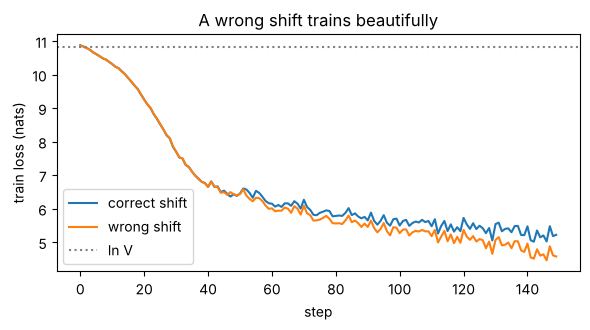

In [13]:
def wrong_shift_loss(logits, tokens):
    return F.cross_entropy(logits[:, 1:].reshape(-1, logits.size(-1)).float(), tokens[:, :-1].reshape(-1))

WRONG_STEPS = min(150, STEPS)
torch.manual_seed(SEEDS[0])
bad = LM().to(DEVICE)
bad_log = train(bad, loss_fn=lambda x: wrong_shift_loss(bad.head(bad.body(x)), x), steps=WRONG_STEPS,
                seed=SEEDS[0], verbose=False)
good_curve = single[SEEDS[0]]["log"]["train_loss"][:WRONG_STEPS]
print(f"train loss after {WRONG_STEPS} steps:  wrong shift {sum(bad_log['train_loss'][-10:]) / 10:.4f}   "
      f"correct shift {sum(good_curve[-10:]) / 10:.4f}")

bad.eval()
wrong_val_correct_harness = evaluate(bad.body, bad.head)
print(f"the wrong-shift model scored by the CORRECT harness: val loss {wrong_val_correct_harness:.3f} "
      f"(perplexity {math.exp(wrong_val_correct_harness):,.0f}; untrained was {untrained_ppl:,.0f})")

with torch.no_grad():
    xs = get_batch("val", B=1, gen=torch.Generator().manual_seed(5))
    pb = bad.head(bad.body(xs)).argmax(-1)[0].cpu()
    pg = lm.head(lm.body(xs)).argmax(-1)[0].cpu()
xs = xs[0].cpu()
print(f"\n{'pos':>4}  {'input':14s} {'true next':14s} {'wrong-shift model says':24s} {'correct model says':20s}")
for t in range(20, 32):
    print(f"{t:>4}  {tok_str(xs[t]):14s} {tok_str(xs[t+1]):14s} {tok_str(pb[t]):24s} {tok_str(pg[t]):20s}")
copy_rate = (pb[1:] == xs[:-1]).float().mean().item()
print(f"\nwrong-shift model's top prediction at t equals the PREVIOUS input token (t-1) at {100 * copy_rate:.0f}% of positions"
      f" -- it learned to copy what it has already seen")

plt.figure(figsize=(6, 3.4))
plt.plot(good_curve, label="correct shift"); plt.plot(bad_log["train_loss"], label="wrong shift")
plt.axhline(math.log(V), ls=":", c="gray", label="ln V"); plt.xlabel("step"); plt.ylabel("train loss (nats)")
plt.title("A wrong shift trains beautifully"); plt.legend(); plt.tight_layout()
plt.savefig("wrong_shift.png", dpi=120); plt.show()

## Item 4 — pack two documents into one sequence and mask the boundary

Documents are packed as `docA <|endoftext|> docB <|endoftext|> ...`, as a pre-training pipeline would.
To make the packed documents genuinely unrelated (as in real packing), validation speeches are shuffled
before packing, so neighbours are not consecutive lines from the same scene.

* **Boundary mask (targets).** The `<|endoftext|>` that *ends* a document stays a target: the model should learn
  when a document ends. The one prediction that crosses documents, made at the `<|endoftext|>` position and
  scored against the **first token of the next document**, is masked.
* **Document-isolated attention (optional second step).** Tokens of B also cannot attend to A, and B's position ids
  restart at 0, so B is processed exactly as if it were alone (checked numerically below).

Explicit demo first: exactly two documents, with the strings around the seam.

In [14]:
def pack(doc_list, T):
    "Greedy pack; returns tokens (L,) and doc_id (L,), L <= T. An EOT belongs to the doc it ends."
    toks, dids = [], []
    for k, d in enumerate(doc_list):
        e = enc.encode_ordinary(d) + [EOT]
        toks += e; dids += [k] * len(e)
        if len(toks) >= T:
            break
    return torch.tensor(toks[:T]), torch.tensor(dids[:T])

def boundary_target_mask(doc_id):
    "(B,T) doc ids -> (B,T-1): False exactly where the target is in a different document."
    return doc_id[:, 1:] == doc_id[:, :-1]

def doc_attention_mask(doc_id):
    "(B,T) -> (B,1,T,T) causal AND same-document. The diagonal is always allowed, so no row is empty."
    T_ = doc_id.size(1)
    causal = torch.ones(T_, T_, dtype=torch.bool, device=doc_id.device).tril()
    same = doc_id[:, :, None] == doc_id[:, None, :]
    return (causal & same)[:, None]

def doc_position_ids(doc_id):
    "(B,T) -> (B,T) position within each document (restarts at 0 for every document)."
    T_ = doc_id.size(1)
    idx = torch.arange(T_, device=doc_id.device).expand_as(doc_id)
    start = torch.ones_like(doc_id, dtype=torch.bool)
    start[:, 1:] = doc_id[:, 1:] != doc_id[:, :-1]
    start_idx = torch.where(start, idx, torch.zeros_like(idx)).cummax(dim=1).values
    return idx - start_idx

def isolated_forward(m, x, did):
    return m.head(m.body(x, attn_mask=doc_attention_mask(did), pos_ids=doc_position_ids(did)))

val_shuffled = val_docs[:]; random.Random(0).shuffle(val_shuffled)

# --- the two-document demo
lens = [len(enc.encode_ordinary(sp)) for sp in val_shuffled]
iA = next(i for i in range(len(val_shuffled)) if 40 <= lens[i] <= 70)
iB = next(j for j in range(iA + 1, len(val_shuffled)) if lens[iA] + 1 + lens[j] + 1 <= CFG["T"] and lens[j] >= 20)
docA, docB = val_shuffled[iA], val_shuffled[iB]
seq, did = pack([docA, docB], T=CFG["T"])
seq, did = seq[None].to(DEVICE), did[None].to(DEVICE)
Lp = seq.size(1)
bmask = boundary_target_mask(did)
seam = int((~bmask[0]).nonzero()[0])                       # position t whose target crosses A -> B

lm.eval()
with torch.no_grad():
    lg = lm.head(lm.body(seq))
    per_tok, _ = lm_loss(lg, seq, reduction="none")
    loss_before, n_before = lm_loss(lg, seq)
    loss_after,  n_after  = lm_loss(lg, seq, bmask)
    lg_iso = isolated_forward(lm, seq, did)
    loss_iso, n_iso = lm_loss(lg_iso, seq, bmask)
    b0 = seam + 1                                              # first token of doc B
    alone = lm.head(lm.body(seq[:, b0:]))
    iso_vs_alone = (lg_iso[:, b0:] - alone).abs().max().item()

print(f"doc A: {len(enc.encode_ordinary(docA))} tokens, doc B: {len(enc.encode_ordinary(docB))} tokens, packed length {Lp}")
print("doc A ends:", repr(docA[-60:]))
print("doc B starts:", repr(docB[:60]))
show_shift(seq[0].cpu(), shifted_targets(seq, bmask)[0].cpu(), start=seam - 4, n=8,
           title=f"\nstrings around the seam (seam at position {seam}):")
others = per_tok[torch.arange(per_tok.numel(), device=DEVICE) != seam]
print(f"\nloss on the cross-document prediction alone = {per_tok[seam].item():.3f} nats  vs mean of the others = {others.mean().item():.3f}")
print(f"before boundary mask : loss = {loss_before.item():.4f} over {n_before} targets")
print(f"after  boundary mask : loss = {loss_after.item():.4f} over {n_after} targets")
print(f"+ doc-isolated attention and positions: loss = {loss_iso.item():.4f} over {n_iso} targets")
print(f"check: doc B isolated inside the pack vs doc B run alone, max |logit diff| = {iso_vs_alone:.2e}")
two_doc = dict(before=loss_before.item(), after=loss_after.item(), n_before=n_before, n_after=n_after,
               seam=per_tok[seam].item(), others=others.mean().item(), iso=loss_iso.item())

doc A: 64 tokens, doc B: 29 tokens, packed length 95
doc A ends: "eyes, never since at ebb, beheld\nThe king my father wreck'd."
doc B starts: 'BIANCA:\nHead, and butt! an hasty-witted body\nWould say your '

strings around the seam (seam at position 64):
 pos  input (sees up to here)      -> target (what must be predicted)
  60  ' father'                    -> ' wreck'
  61  ' wreck'                     -> "'d"
  62  "'d"                         -> '.'
  63  '.'                          -> '<|endoftext|>'
  64  '<|endoftext|>'              -> <IGNORED>
  65  'BI'                         -> 'AN'
  66  'AN'                         -> 'CA'
  67  'CA'                         -> ':'

loss on the cross-document prediction alone = 5.977 nats  vs mean of the others = 5.212
before boundary mask : loss = 5.2196 over 94 targets
after  boundary mask : loss = 5.2115 over 93 targets
+ doc-isolated attention and positions: loss = 5.2202 over 93 targets
check: doc B isolated inside the pack vs doc B 

Now the same measurement over many packed sequences, so the numbers are not one lucky seam. Targets are split into three kinds: ordinary in-document, end-of-document (`<|endoftext|>` as the target), and seam (the cross-document prediction).

In [15]:
def packed_batches(docs, n_seq=64, T=CFG["T"]):
    seqs, dids, k = [], [], 0
    while len(seqs) < n_seq and k < len(docs):
        s, d = pack(docs[k:k + 50], T)
        if len(s) < T:
            break
        k += int(d[-1]) + 1      # the last doc was cut at T; drop its tail and start the next pack with a fresh doc
        seqs.append(s); dids.append(d)
    return torch.stack(seqs).to(DEVICE), torch.stack(dids).to(DEVICE)

pk, pd = packed_batches(val_shuffled)
bm = boundary_target_mask(pd)
is_eot_tgt = (pk[:, 1:] == EOT) & bm
is_plain = bm & ~is_eot_tgt
tok_loss, tok_loss_iso = [], []
with torch.no_grad():                               # 8 sequences at a time: 64 x 128 x 50257 logits would be 1.6 GB
    for i in range(0, pk.size(0), 8):
        xs, ds = pk[i:i + 8], pd[i:i + 8]
        tok_loss.append(lm_loss(lm.head(lm.body(xs)), xs, reduction="none")[0])
        tok_loss_iso.append(lm_loss(isolated_forward(lm, xs, ds), xs, reduction="none")[0])
tok_loss = torch.cat(tok_loss).view(bm.shape)
tok_loss_iso = torch.cat(tok_loss_iso).view(bm.shape)
pack_before, pn_before = tok_loss.mean(), bm.numel()          # every target counts
pack_after,  pn_after  = tok_loss[bm].mean(), int(bm.sum())   # seam targets dropped
pack_iso = tok_loss_iso[bm].mean()

n_seams = int((~bm).sum())
seam_l, eot_l, plain_l = tok_loss[~bm].mean().item(), tok_loss[is_eot_tgt].mean().item(), tok_loss[is_plain].mean().item()
print(f"{pk.size(0)} packed sequences, {n_seams} seams ({n_seams / pk.size(0):.1f} per sequence)")
print(f"mean loss by target kind:  in-document {plain_l:.3f} ({int(is_plain.sum())})   "
      f"end-of-document {eot_l:.3f} ({int(is_eot_tgt.sum())})   seam {seam_l:.3f} ({n_seams})")
print(f"before boundary mask : {pack_before.item():.4f}  over {pn_before} targets")
print(f"after  boundary mask : {pack_after.item():.4f}  over {pn_after} targets  (difference {pack_before.item() - pack_after.item():+.4f})")
print(f"+ doc-isolated attention and positions: {pack_iso.item():.4f}")
print(f"  of which seam-adjacent effect: first 8 tokens of each later document, "
      f"shared {tok_loss[:, :][doc_position_ids(pd)[:, 1:].lt(8) & bm & (pd[:, 1:] > 0)].mean().item():.3f} "
      f"vs isolated {tok_loss_iso[doc_position_ids(pd)[:, 1:].lt(8) & bm & (pd[:, 1:] > 0)].mean().item():.3f}")

64 packed sequences, 244 seams (3.8 per sequence)
mean loss by target kind:  in-document 4.894 (7639)   end-of-document 0.638 (245)   seam 6.686 (244)
before boundary mask : 4.8197  over 8128 targets
after  boundary mask : 4.7619  over 7884 targets  (difference +0.0577)
+ doc-isolated attention and positions: 4.7694
  of which seam-adjacent effect: first 8 tokens of each later document, shared 3.606 vs isolated 3.665


**What the difference means.** *(numbers quoted here are from the committed run)*

* **Seam targets are much harder than ordinary ones: 6.69 nats vs 4.89.** The target at a seam is the first piece of
  the next speaker's name (`'BI'` of `BIANCA:` above). An unrelated previous speech says almost nothing about who
  speaks next, so the model can only fall back on its prior over speaker names.
* **End-of-document targets are easy (0.64 nats) and stay in.** Predicting that a speech is over, from the speech
  itself, is legitimate and the model has learned it. This is why the mask is `doc_id[t+1] == doc_id[t]` and not
  "mask everything near `<|endoftext|>`".
* **Masking removes exactly one target per seam (8,128 → 7,884, i.e. 244 seams) and the loss falls from 4.820 to 4.762.**
  The size of the drop is (244 / 8,128) × (6.686 − 4.762) = 0.058. That is an identity of means, so it describes the size of
  the change; it is not independent evidence. The evidence is the per-kind losses above. In the two-document demo
  the same thing happens at a single seam: 5.98 nats at the seam vs 5.21 elsewhere, loss 5.220 → 5.212.
* **Why it matters.** Unmasked, the reported loss mixes in a quantity no model could learn from context, and it varies
  with how many documents happen to be packed per sequence. In training, it rewards memorising which speaker tends
  to follow which, across documents that are adjacent only because of the packer.

**Document-isolated attention is a separate change, and here it does not lower the loss (4.769 vs 4.762).** The check
above shows the isolation is exact (doc B inside the pack equals doc B alone to 7e-6). The small increase sits in the
first few tokens of each later document (3.61 → 3.67 nats on the first 8). There are two reasons:
(1) the model was trained with attention across `<|endoftext|>`, so a speech that starts with no context at all is
slightly off its training distribution; (2) the validation speeches all come from two plays (*The Taming of the
Shrew* and *The Tempest*), so even a shuffled neighbour shares character names and vocabulary.
Isolation is about not leaking information between unrelated samples. It pays off when training uses it too.

# Part 2 — a second head predicting token `t+2`

Same body. Head 1 is the tied unembedding (next token). Head 2 is a residual MLP followed by the **same**
tied unembedding, the shape of a Medusa head (Cai et al., 2024), so it adds one small block rather than a second
6.4 M-parameter matrix, and it must turn the hidden state into "the token after next".

Shift for head 2: position `t` is scored against `tokens[t+2]`, so `logits2[:, :-2]` vs `tokens[:, 2:]`.
Strings first, as before.

In [16]:
class Plus2Head(nn.Module):
    def __init__(self, d, unembed):
        super().__init__()
        self.ln = nn.LayerNorm(d)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d))
        nn.init.zeros_(self.mlp[2].weight); nn.init.zeros_(self.mlp[2].bias)
        self.unembed = unembed                       # shared, tied
    def forward(self, h):
        return self.unembed(self.ln(h + self.mlp(h)))

def k_ahead_loss(logits, tokens, k, reduction="mean"):
    "position t is scored against tokens[t+k]"
    V_ = logits.size(-1)
    return F.cross_entropy(logits[:, :-k].reshape(-1, V_).float(), tokens[:, k:].reshape(-1),
                           ignore_index=IGNORE, reduction=reduction)

class LM2(nn.Module):
    def __init__(self):
        super().__init__()
        self.body = TinyGPT(V, **CFG)
        self.head1 = make_head(self.body, tied=True)
        self.head2 = Plus2Head(CFG["d"], self.head1)
    def losses(self, x):
        h = self.body(x)
        return k_ahead_loss(self.head1(h), x, 1), k_ahead_loss(self.head2(h), x, 2)

x = get_batch("train", B=1, gen=torch.Generator().manual_seed(3))[0].cpu()
print(f"{'pos':>4}  {'input':16s} -> {'head1 target (t+1)':20s} {'head2 target (t+2)':20s}")
for t in range(10):
    print(f"{t:>4}  {tok_str(x[t]):16s} -> {tok_str(x[t+1]):20s} {tok_str(x[t+2]):20s}")

 pos  input            -> head1 target (t+1)   head2 target (t+2)  
   0  '<|endoftext|>'  -> 'Children'           ':'                 
   1  'Children'       -> ':'                  '\n'                
   2  ':'              -> '\n'                 'Were'              
   3  '\n'             -> 'Were'               ' never'            
   4  'Were'           -> ' never'             ' orphans'          
   5  ' never'         -> ' orphans'           ' had'              
   6  ' orphans'       -> ' had'               ' so'               
   7  ' had'           -> ' so'                ' dear'             
   8  ' so'            -> ' dear'              ' a'                
   9  ' dear'          -> ' a'                 ' loss'             


In [17]:
@torch.no_grad()
def evaluate2(m, n_batches=20, seed=1234):
    g = torch.Generator().manual_seed(seed)
    s1 = s2 = 0.0
    for _ in range(n_batches):
        l1, l2 = m.losses(get_batch("val", gen=g)); s1 += l1.item(); s2 += l2.item()
    return dict(val_head1=s1 / n_batches, val_head2=s2 / n_batches)

two = {}
for s in SEEDS:
    print(f"--- two-head, seed {s}")
    torch.manual_seed(s)
    m2 = LM2().to(DEVICE)
    parts = []
    def loss2(x, m2=m2, parts=parts):
        l1, l2 = m2.losses(x)
        parts.append((l1.item(), l2.item()))
        return l1 + l2
    log = train(m2, loss_fn=loss2, eval_fn=lambda m2=m2: evaluate2(m2), seed=s)
    two[s] = dict(model=m2, log=log, parts=parts)
lm2 = two[SEEDS[0]]["model"]
print("\nparameters: single-head", f"{n_params(lm):,}", "| two-head", f"{n_params(lm2):,}",
      f"(+{n_params(lm2) - n_params(lm):,} for head 2)")

--- two-head, seed 0


step    0  val_head1=10.8689  val_head2=10.8625  (23s)


step   75  val_head1=6.3217  val_head2=6.5876  (275s)


step  150  val_head1=5.6519  val_head2=6.1418  (528s)


step  225  val_head1=5.3804  val_head2=6.0204  (775s)


...

step  300  val_head1=5.2853  val_head2=5.9765  (1007s)


step  375  val_head1=5.1511  val_head2=5.8819  (1251s)


step  450  val_head1=5.0768  val_head2=5.8292  (1490s)


step  525  val_head1=5.0566  val_head2=5.8150  (1733s)


step  600  val_head1=5.0476  val_head2=5.8081  (1973s)

parameters: single-head 7,242,624 | two-head 7,374,592 (+131,968 for head 2)


validation loss, mean over seeds [0, 1]
 step  head1 (t+1)  head2 (t+2)      sum     gap  single-head t+1        lr
    0      10.8606      10.8565  21.7170  -0.004          10.8606  4.00e-05
   75       6.2974       6.5609  12.8582   0.264           6.1044  1.99e-03
  150       5.6308       6.1304  11.7612   0.500           5.4655  1.84e-03
  225       5.3873       6.0259  11.4132   0.639           5.2467  1.54e-03
  300       5.2505       5.9456  11.1960   0.695           5.1399  1.14e-03
  375       5.1387       5.8611  10.9998   0.722           5.0558  7.18e-04
  450       5.0747       5.8234  10.8981   0.749           4.9923  3.45e-04
  525       5.0470       5.8017  10.8487   0.755           4.9668  9.04e-05
  600       5.0379       5.7923  10.8301   0.754           4.9567  1.63e-08

per seed, final:
  seed 0: head1 5.0282  head2 5.7765  sum 10.8046  | single-head 4.9571  -> two-head minus single-head +0.0711
  seed 1: head1 5.0476  head2 5.8081  sum 10.8557  | single-head 4.9564

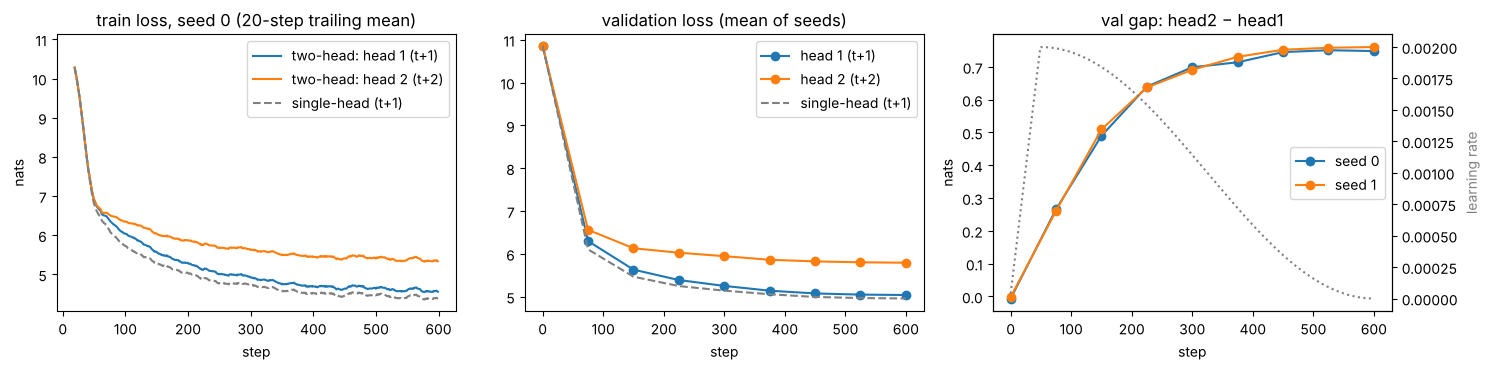

In [18]:
steps = [r["step"] for r in two[SEEDS[0]]["log"]["hist"]]
mean = lambda xs: sum(xs) / len(xs)
V1 = {s: [r["val_head1"] for r in two[s]["log"]["hist"]] for s in SEEDS}
V2 = {s: [r["val_head2"] for r in two[s]["log"]["hist"]] for s in SEEDS}
B1 = {s: [r["val_loss"] for r in single[s]["log"]["hist"]] for s in SEEDS}
v1 = [mean([V1[s][i] for s in SEEDS]) for i in range(len(steps))]
v2 = [mean([V2[s][i] for s in SEEDS]) for i in range(len(steps))]
b1 = [mean([B1[s][i] for s in SEEDS]) for i in range(len(steps))]

print(f"validation loss, mean over seeds {SEEDS}")
print(f"{'step':>5} {'head1 (t+1)':>12} {'head2 (t+2)':>12} {'sum':>8} {'gap':>7} {'single-head t+1':>16} {'lr':>9}")
for i, s in enumerate(steps):
    print(f"{s:5d} {v1[i]:12.4f} {v2[i]:12.4f} {v1[i] + v2[i]:8.4f} {v2[i] - v1[i]:7.3f} {b1[i]:16.4f} {lr_at(min(s, STEPS - 1)):9.2e}")

print("\nper seed, final:")
for s in SEEDS:
    print(f"  seed {s}: head1 {V1[s][-1]:.4f}  head2 {V2[s][-1]:.4f}  sum {V1[s][-1] + V2[s][-1]:.4f}  "
          f"| single-head {B1[s][-1]:.4f}  -> two-head minus single-head {V1[s][-1] - B1[s][-1]:+.4f}")
seed_noise = max(B1[s][-1] for s in SEEDS) - min(B1[s][-1] for s in SEEDS)
print(f"seed-to-seed spread of the single-head final loss: {seed_noise:.4f}")

i150 = steps.index(min(steps, key=lambda s: abs(s - STEPS // 4)))
print(f"\nimprovement from step {steps[i150]} to {steps[-1]}: head1 {v1[i150] - v1[-1]:.3f}, head2 {v2[i150] - v2[-1]:.3f} nats")
half = STEPS // 2
print(f"steps with clipping active (second half of training): single-head "
      f"{mean([clip_frac(single[s]['log'], half) for s in SEEDS]):.0%}, two-head {mean([clip_frac(two[s]['log'], half) for s in SEEDS]):.0%}")
print(f"mean pre-clip grad norm (second half): single-head "
      f"{mean([mean(single[s]['log']['grad_norm'][half:]) for s in SEEDS]):.3f}, "
      f"two-head {mean([mean(two[s]['log']['grad_norm'][half:]) for s in SEEDS]):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
w = min(20, STEPS)
def smooth(v):
    v = torch.tensor(v, dtype=torch.float)
    return torch.arange(w - 1, len(v)), F.avg_pool1d(v[None, None], w, 1)[0, 0]
tl = torch.tensor(two[SEEDS[0]]["parts"])
ax[0].plot(*smooth(tl[:, 0].tolist()), label="two-head: head 1 (t+1)")
ax[0].plot(*smooth(tl[:, 1].tolist()), label="two-head: head 2 (t+2)")
ax[0].plot(*smooth(single[SEEDS[0]]["log"]["train_loss"]), ls="--", c="gray", label="single-head (t+1)")
ax[0].set_title(f"train loss, seed {SEEDS[0]} ({w}-step trailing mean)"); ax[0].set_xlabel("step"); ax[0].set_ylabel("nats")
ax[0].legend(); ax[0].set_ylim(top=math.log(V) + 0.3)
ax[1].plot(steps, v1, marker="o", label="head 1 (t+1)"); ax[1].plot(steps, v2, marker="o", label="head 2 (t+2)")
ax[1].plot(steps, b1, ls="--", c="gray", label="single-head (t+1)")
ax[1].set_title("validation loss (mean of seeds)"); ax[1].set_xlabel("step"); ax[1].legend(); ax[1].set_ylim(top=math.log(V) + 0.3)
for s in SEEDS:
    ax[2].plot(steps, [b - a for a, b in zip(V1[s], V2[s])], marker="o", label=f"seed {s}")
ax2 = ax[2].twinx(); ax2.plot(range(STEPS), [lr_at(i) for i in range(STEPS)], c="gray", ls=":", label="learning rate")
ax2.set_ylabel("learning rate", color="gray")
ax[2].set_title("val gap: head2 − head1"); ax[2].set_xlabel("step"); ax[2].set_ylabel("nats"); ax[2].legend(loc="center right")
plt.tight_layout(); plt.savefig("part2_losses.png", dpi=120); plt.show()

**What happens and why.** *(numbers quoted here are from the committed run, mean of seeds 0 and 1)*

* **Together, then apart.** Both heads start at ≈ ln V and fall together during warm-up, while the body learns things
  that help at any offset (token frequencies, common words, the `NAME:\n` layout). Then they separate. The
  validation gap grows from 0.26 nats (step 75) to 0.50 (150) and 0.70 (300), reaches 0.75 at step 450, and is flat after
  that (0.755, 0.754). The two seeds agree to within 0.02 at every step.
* **Head 2 stops improving earlier.** From step 150 to 600, head 1 improves by 0.59 nats and head 2 by only 0.34.
* **Why the gap exists.** For a stationary source, H(X<sub>t+2</sub> | X<sub>≤t</sub>) ≥ H(X<sub>t+2</sub> | X<sub>≤t+1</sub>)
  = H(X<sub>t+1</sub> | X<sub>≤t</sub>), because conditioning on less cannot reduce entropy. So head 2's best possible loss
  is *at least* head 1's, with equality only if token t+1 tells you nothing about t+2. For text it tells you a lot:
  much of the easy structure in BPE text (finishing a word split into pieces, punctuation, the newline after
  `NAME:`) is about the very next token. Head 1 keeps collecting that; head 2 can't.
* **What this run cannot separate.** Both heads are far above any entropy floor, so the gap's *size* also reflects head
  2's smaller capacity (one MLP block on top of the shared body). And the flattening after step 450 coincides with the
  cosine schedule, where the learning rate is already down to 17% of peak and falls to zero.
* **The cost to next-token prediction.** The two-head model's head 1 ends at 5.038, against 4.957 for the single-head
  model: +0.071 and +0.091 nats for seeds 0 and 1. The single-head seeds differ from each other by only 0.0007, so the
  cost is real for this setup. A 0.8 M-parameter body has little spare capacity, and the harder t+2 objective
  competes for it. This matches Gloeckle et al. (2024), *Better & Faster Large Language Models via Multi-token Prediction*,
  where extra future-token heads hurt small models and help only at billions of parameters.
* **One caveat on that comparison.** The summed loss has about 1.8× the gradient norm (1.34 vs 0.73 in the second half),
  so it is clipped on 99% of those steps against 1% for the single-head model. With Adam, a roughly constant
  rescaling cancels in m/√v, so this is unlikely to explain 0.08 nats, but it is not tested here.

## Summary of the numbers (filled from this run)

In [19]:
summary = {
    "1. shapes": f"tokens {tuple(tokens.shape)}, hidden {tuple(hidden.shape)}, logits {tuple(logits.shape)}, "
                 f"pred {tuple(pred.shape)}, tgt {tuple(tgt.shape)}, loss ()",
    "2. shift check": f"{mismatches} mismatches vs corpus over {harness_tgt.numel()} positions; wrong shift trains to "
                      f"{mean(bad_log['train_loss'][-10:]):.3f} vs correct {mean(good_curve[-10:]):.3f} at step {WRONG_STEPS}, "
                      f"but scores {wrong_val_correct_harness:.2f} under the correct harness",
    "3. padding": f"contributing tokens {n_nomask} -> {n_mask}; loss {loss_nomask.item():.4f} -> {loss_mask.item():.4f}",
    "4a. packing, two docs": f"loss {two_doc['before']:.4f} -> {two_doc['after']:.4f} over {two_doc['n_before']} -> {two_doc['n_after']} "
                             f"targets; seam {two_doc['seam']:.3f} vs others {two_doc['others']:.3f}; isolated {two_doc['iso']:.4f}",
    "4b. packing, 64 seqs": f"loss {pack_before.item():.4f} -> {pack_after.item():.4f} over {pn_before} -> {pn_after} targets; "
                            f"seam {seam_l:.3f}, end-of-doc {eot_l:.3f}, in-doc {plain_l:.3f}; isolated {pack_iso.item():.4f}",
    "5. untrained perplexity": f"{untrained_ppl:,.0f} vs V = {V} (ratio {untrained_ppl / V:.3f}; predicted {pred_ratio:.3f})",
    "6. params": f"tied {tied_total:,} vs untied {untied_total:,} (+{untied_total - tied_total:,})",
    "7. peak memory": f"ordinary {ordinary['peak_bytes'] / MiB:,.1f} MiB vs chunked(256) {chunked['peak_bytes'] / MiB:,.1f} MiB "
                      f"-> {mem_ratio:.1f}x ({ordinary['device']}, {ordinary['method']}); sweep "
                      + ", ".join(f"{c}:{r['peak_bytes'] / MiB:,.1f}" for c, r in sweep.items()),
    "Part 2": f"mean of seeds {SEEDS}: head1 {v1[-1]:.4f}, head2 {v2[-1]:.4f}, sum {v1[-1] + v2[-1]:.4f}; "
              f"single-head {b1[-1]:.4f}",
}
for k, v in summary.items():
    print(f"{k:24s} {v}")
json.dump(summary, open("summary.json", "w"), indent=2)

1. shapes                tokens (4, 128), hidden (4, 128, 128), logits (4, 128, 50257), pred (508, 50257), tgt (508,), loss ()
2. shift check           0 mismatches vs corpus over 508 positions; wrong shift trains to 4.655 vs correct 5.214 at step 150, but scores 8.81 under the correct harness
3. padding               contributing tokens 88 -> 44; loss 10.6952 -> 10.8007
4a. packing, two docs    loss 5.2196 -> 5.2115 over 94 -> 93 targets; seam 5.977 vs others 5.212; isolated 5.2202
4b. packing, 64 seqs     loss 4.8197 -> 4.7619 over 8128 -> 7884 targets; seam 6.686, end-of-doc 0.638, in-doc 4.894; isolated 4.7694
5. untrained perplexity  52,518 vs V = 50257 (ratio 1.045; predicted 1.026)
6. params                tied 7,242,624 vs untied 13,675,520 (+6,432,896)
7. peak memory           ordinary 1,179.6 MiB vs chunked(256) 102.2 MiB -> 11.5x (cpu, VmHWM (reset)); sweep 64:65.0, 256:102.2, 1024:396.0
Part 2                   mean of seeds [0, 1]: head1 5.0379, head2 5.7923, sum 10.8301; 